In [1]:
import cv2
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import Preprocessing
import json 

import pytesseract
tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
pytesseract.pytesseract.tesseract_cmd = tesseract_path

In [2]:
# load config:
try:
    with open("config.json", "r", encoding="utf-8") as file:
        loaded_config = json.load(file)
        print("Config successfully loaded!")
except FileNotFoundError:
    print("Error: config.json not found. Falling back to default settings.")
    loaded_config = {}
except json.JSONDecodeError:
    print("Error: Invalid JSON format in config.json. Please check your syntax.")
    loaded_config = {}

Config successfully loaded!


In [3]:
pipeline = Preprocessing(config=loaded_config)
    
image_path = "data/input/preprocess/31.png"

Error during rotation detection: (1, 'Estimating resolution as 609 Too few characters. Skipping this page Warning. Invalid resolution 0 dpi. Using 70 instead. Too few characters. Skipping this page Error during processing.'), no rotation was done.

--- Pipeline Results ---
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)', 'qr_codes': []}


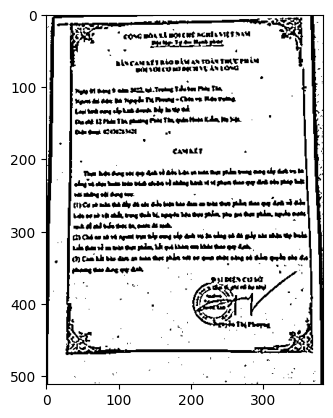

In [4]:
test_image = cv2.imread(image_path)

if test_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # processed_image, meta_data = pipeline._process(test_image)
    result = pipeline._process(test_image)
    processed_image = result.image
    meta_data = result.metadata
    print("\n--- Pipeline Results ---")
    print(f"Metadata: {meta_data}")
    
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.show()

In [5]:
print(result)

IMAGE
  size     : 384 x 512
  channels : 1
  dtype    : uint8

METADATA
  status     : success
  is_blank   : False
  confidence : 0.9808
  qr_count   : 0


Loaded 51 images
Processed and saved: 1.png
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9456258857366263, 'comment': 'rf_model (score=0.0544)', 'qr_codes': []}
Processed and saved: 2.png
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)', 'qr_codes': []}
Processed and saved: 3.png
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)', 'qr_codes': [CodeResult(type='QRCODE', content='https://q.me-qr.com/rmtmfu2a', bbox=(1365, 1961, 239, 239), polygon=[(1365, 1961), (1365, 2200), (1604, 2200), (1604, 1961)], quality=1)]}
Processed and saved: 4.png
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.989001796628183, 'comment': 'rf_model (score=0.0110)', 'qr_codes': []}
Processed and saved: 5.png
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)',

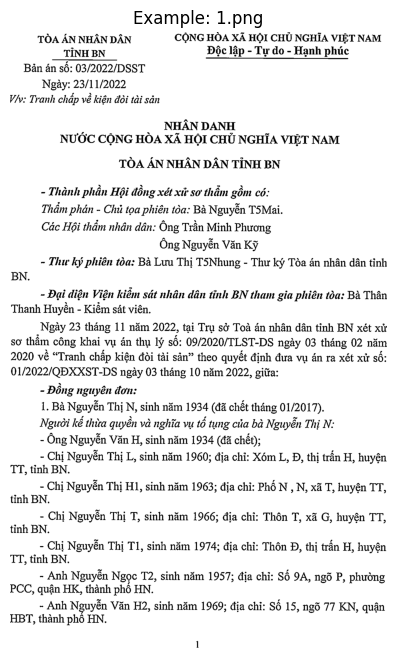

In [6]:
import os
import cv2
import matplotlib.pyplot as plt # Đảm bảo bạn đã import thư viện này

pipeline = Preprocessing(config=loaded_config)

# === Đường dẫn thư mục ===
input_folder = r"data\input\preprocess"
output_folder = r"data\output\preprocess" 

# Tạo thư mục output nếu nó chưa tồn tại
os.makedirs(output_folder, exist_ok=True)

# === Collect all image paths (sorted numerically!) ===
def numeric_sort_key(filename):
    name, _ = os.path.splitext(filename)
    try:
        return int(name)
    except:
        return float('inf')

image_files = sorted(
    [f for f in os.listdir(input_folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))],
    key=numeric_sort_key
)

image_paths = [os.path.join(input_folder, f) for f in image_files]

print(f"Loaded {len(image_paths)} images")

# === Process and SAVE all images ===
results = []

for image_path in image_paths:
    test_image = cv2.imread(image_path)

    if test_image is None:
        print(f"Error: Could not load {image_path}")
        continue

    # Chạy pipeline xử lý
    result = pipeline._process(test_image)
    
    # Lấy tên file gốc (ví dụ: '1.png')
    filename = os.path.basename(image_path)
    
    # Tạo đường dẫn lưu file mới
    output_path = os.path.join(output_folder, filename)
    
    # LƯU ẢNH XUỐNG Ổ CỨNG
    cv2.imwrite(output_path, result.image)

    # Vẫn lưu vào RAM nếu bạn cần dùng list `results` cho việc khác
    results.append({
        "path": image_path,
        "output_path": output_path,
        "image": result.image,
        "metadata": result.metadata
    })

    print(f"Processed and saved: {filename}")
    print(f"Metadata: {result.metadata}")

print(f"\n✅ Đã lưu toàn bộ {len(results)} ảnh thành công tại thư mục: {output_folder}")

# === Example: show first result ===
if results:
    first = results[0]
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(first["image"], cv2.COLOR_BGR2RGB))
    plt.title(f"Example: {os.path.basename(first['path'])}")
    plt.axis('off')
    plt.show()